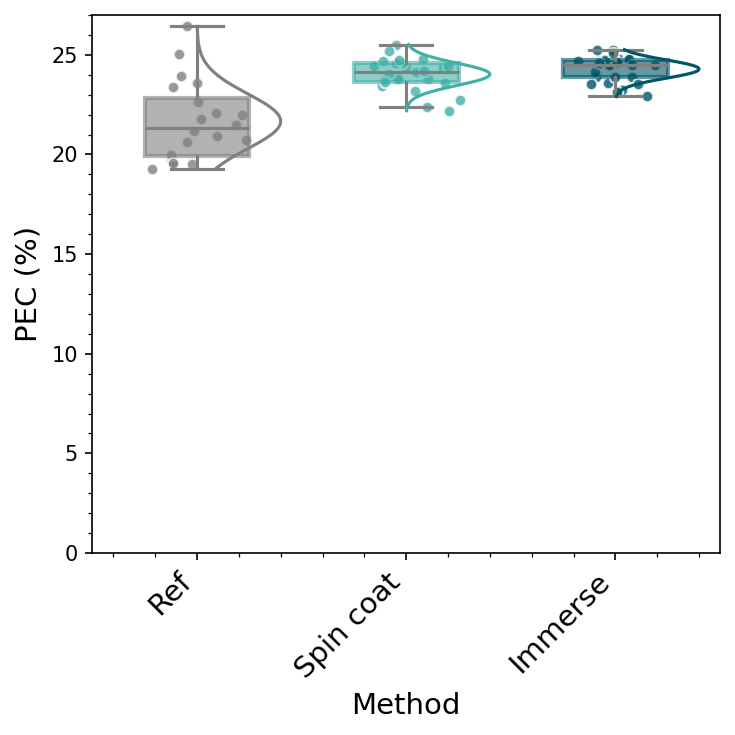

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
# Ref
data_ref = np.random.normal(21.5, 1.5, 20)
# Spin coat
data_spin = np.random.normal(24.0, 0.8, 25)
# Immerse
data_imm = np.random.normal(24.2, 0.6, 25)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

# Colors
c_ref = 'gray'
c_spin = '#40B0A6' # Teal
c_imm = '#005566' # Dark Teal

# 1. Boxplots
bplot = ax.boxplot([data_ref, data_spin, data_imm], positions=[1, 2, 3], widths=0.5,
                   patch_artist=True, showfliers=False)

# Color boxes
colors = [c_ref, c_spin, c_imm]
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor(color)
    patch.set_linewidth(2)

for element in ['whiskers', 'caps', 'medians']:
    plt.setp(bplot[element], color='gray', linewidth=1.5)

# 2. Scatter (Jittered)
x_ref = np.random.normal(1, 0.1, len(data_ref))
ax.scatter(x_ref, data_ref, color='gray', edgecolor='white', s=30, alpha=0.8)

x_spin = np.random.normal(2, 0.1, len(data_spin))
ax.scatter(x_spin, data_spin, color=c_spin, edgecolor='white', s=30, alpha=0.8)

x_imm = np.random.normal(3, 0.1, len(data_imm))
ax.scatter(x_imm, data_imm, color=c_imm, edgecolor='white', s=30, alpha=0.8)

# 3. Density Curves (Half Violin approximation)
# Just drawing a smooth curve to right of box
for i, (data, col) in enumerate(zip([data_ref, data_spin, data_imm], colors)):
    pos = i + 1
    # Simple KDE-like curve
    y_kde = np.linspace(min(data), max(data), 50)
    # Gaussian
    mu = np.mean(data)
    sigma = np.std(data)
    x_kde = pos + 0.4 * np.exp(-((y_kde - mu)/sigma)**2)
    ax.plot(x_kde, y_kde, color=col, lw=1.5)

# Styling
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Ref', 'Spin coat', 'Immerse'], rotation=45, ha='right', fontsize=14)
ax.set_ylabel('PEC (%)', fontsize=14)
ax.set_xlabel('Method', fontsize=14)
ax.set_ylim(0, 27)

# Ticks
ax.minorticks_on()
ax.tick_params(direction='out', top=False, right=False)

plt.tight_layout()
plt.show()
